In [2]:
import pandas as pd
import json
combined_data = pd.read_csv("../datasets/combined_data.csv")

with open("../datasets/combined_features.json", "r") as f:
    selected_features = json.load(f)

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

x = combined_data[selected_features["features"]]
y = combined_data["target"]

# Encode target labels (CANDIDATE / CONFIRMED / FALSE POSITIVE)
le = LabelEncoder()
y = le.fit_transform(y)


scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

numeric_features = x.columns.tolist()

In [43]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # fill missing values
    ("scaler", StandardScaler())                   # normalize
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)


In [4]:
# 📦 Imports
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1️Split dataset
# -----------------------------
# x = features, y = target 
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42)


# -----------------------------
# 3️Define models
# -----------------------------
models = {
    "RandomForest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(
        random_state=42, use_label_encoder=False, eval_metric="mlogloss"
    ),
    "LightGBM": LGBMClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

# -----------------------------
# 4️⃣ Hyperparameter grids
# -----------------------------
param_grids = {
    "RandomForest": {
        "classifier__n_estimators": [100, 200, 500],
        "classifier__max_depth": [None, 5, 10, 20],
        "classifier__min_samples_split": [2, 5, 10]
    },
    "XGBoost": {
        "classifier__n_estimators": [100, 200, 500],
        "classifier__max_depth": [3, 5, 7],
        "classifier__learning_rate": [0.01, 0.05, 0.1],
        "classifier__subsample": [0.7, 0.8, 1.0]
    },
    "LightGBM": {
        "classifier__n_estimators": [100, 200, 500],
        "classifier__max_depth": [-1, 5, 10],
        "classifier__learning_rate": [0.01, 0.05, 0.1],
        "classifier__num_leaves": [31, 50, 100]
    },
    "GradientBoosting": {
        "classifier__n_estimators": [100, 200, 500],
        "classifier__max_depth": [3, 5, 7],
        "classifier__learning_rate": [0.01, 0.05, 0.1]
    }
}

# -----------------------------
# 5️⃣ Cross-validation & tuning
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_models = {}
best_scores = {}

for name, model in models.items():
    print(f"\n🔍 Tuning {name} ...")
    clf = Pipeline(steps=[("preprocessor", preprocessor),
                          ("classifier", model)])
    
    search = RandomizedSearchCV(
        clf,
        param_distributions=param_grids[name],
        n_iter=10,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    
    search.fit(X_train, y_train)
    
    best_models[name] = search.best_estimator_
    best_scores[name] = search.best_score_
    
    print(f"✅ Best CV Accuracy for {name}: {search.best_score_:.4f}")
    print(f"🏆 Best Params: {search.best_params_}")

# -----------------------------
# Print summary of all models
# -----------------------------
print("\n📊 Summary of Best Cross-Validated Accuracy:")
for name, score in best_scores.items():
    print(f"{name}: {score:.4f}")



🔍 Tuning RandomForest ...


NameError: name 'preprocessor' is not defined

In [55]:
# 1️⃣ Extract only the classifier from each best pipeline
ensemble_estimators = [
    (name, model.named_steps["classifier"])  # get the classifier only
    for name, model in best_models.items()
]

# 2️⃣ Preprocess the data manually
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 3️⃣ Create VotingClassifier
ensemble = VotingClassifier(
    estimators=ensemble_estimators,
    voting="soft",
    n_jobs=-1
)

# 4️⃣ Fit and predict
ensemble.fit(X_train_processed, y_train)
y_pred = ensemble.predict(X_test_processed)

# 5️⃣ Evaluate
from sklearn.metrics import accuracy_score
print("Ensemble Accuracy:", accuracy_score(y_test, y_pred))


ValueError: Invalid 'estimators' attribute, 'estimators' should be a non-empty list of (string, estimator) tuples.

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="mlogloss"),
    "LightGBM": LGBMClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f"\n🔍 Tuning {name} ...")
    clf = Pipeline(steps=[("preprocessor", preprocessor),
                          ("classifier", model)])
    
    search = RandomizedSearchCV(
        clf,
        param_distributions=param_grids[name],
        n_iter=10,              # number of random combos to try
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    search.fit(x, y)
    
    results[name] = {
        "best_score": search.best_score_,
        "best_params": search.best_params_
    }
    print(f"✅ Best CV Accuracy: {search.best_score_:.4f}")
    print(f"🏆 Best Params: {search.best_params_}")


In [24]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

# Pick the best model (example: LightGBM)
best_model = LGBMClassifier(**{k.replace("classifier__", ""): v 
                               for k, v in results["LightGBM"]["best_params"].items()},
                               random_state=42)

clf_final = Pipeline(steps=[("preprocessor", preprocessor),
                            ("classifier", best_model)])

clf_final.fit(X_train, y_train)
y_pred = clf_final.predict(X_test)

print("\n🎯 Final Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001966 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3876
[LightGBM] [Info] Number of data points in the train set: 7651, number of used features: 30
[LightGBM] [Info] Start training from score -1.447605
[LightGBM] [Info] Start training from score -1.428337
[LightGBM] [Info] Start training from score -0.644052

🎯 Final Test Accuracy: 0.9048614741244119
                precision    recall  f1-score   support

     CANDIDATE       0.84      0.76      0.80       449
     CONFIRMED       0.82      0.86      0.84       459
FALSE POSITIVE       0.97      0.99      0.98      1005

      accuracy                           0.90      1913
     macro avg       0.88      0.87      0.87      1913
  weighted avg       0.90      0.90      0.90      1913



d:\ML_AI\heart_disease_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


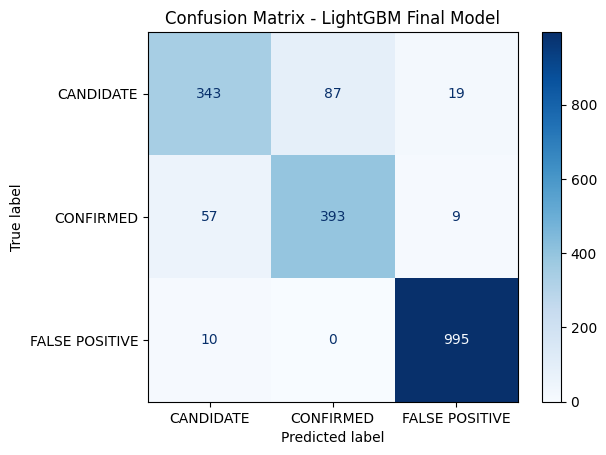

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", values_format="d")  # "d" shows integer counts
plt.title("Confusion Matrix - LightGBM Final Model")
plt.show()

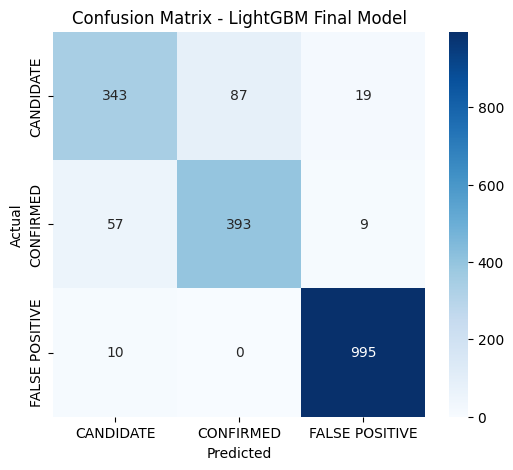

In [29]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LightGBM Final Model")
plt.savefig("../results/confusion_matrix_lightgbm.png", dpi=300, bbox_inches="tight")
plt.show()


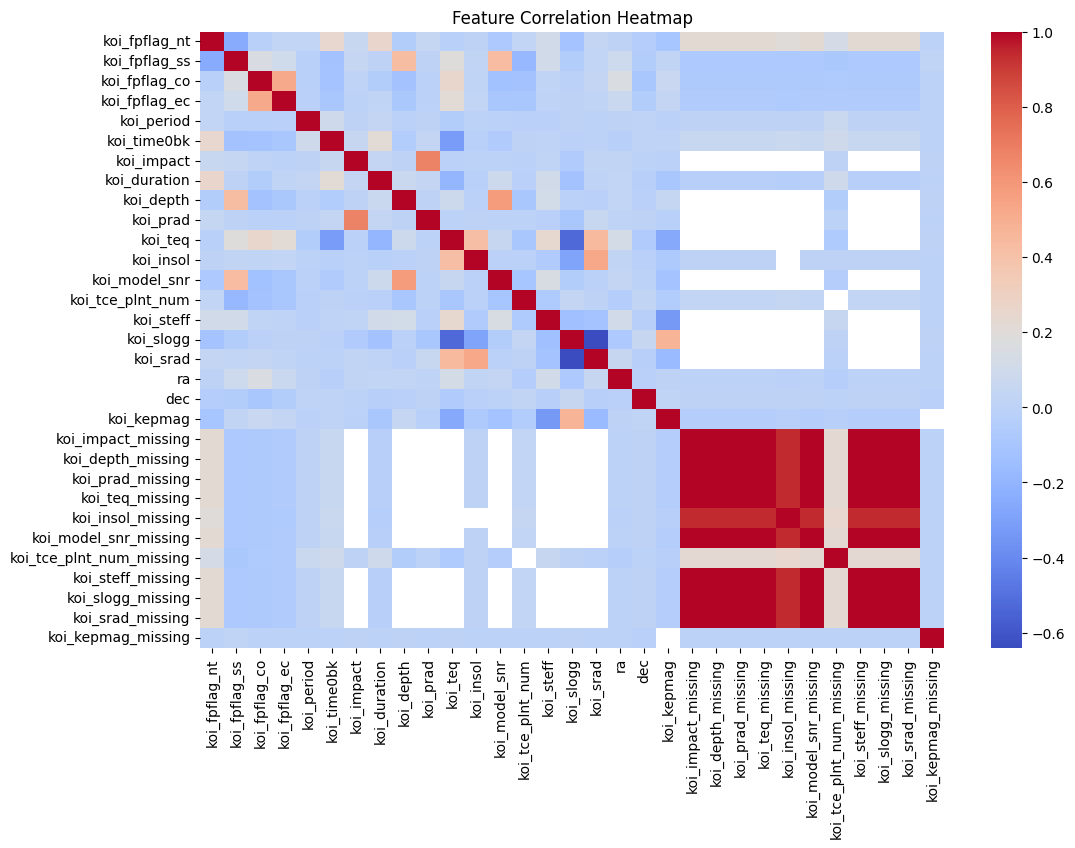

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = x.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Heatmap")
plt.show()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3876
[LightGBM] [Info] Number of data points in the train set: 7651, number of used features: 30
[LightGBM] [Info] Start training from score -1.447605
[LightGBM] [Info] Start training from score -1.428337
[LightGBM] [Info] Start training from score -0.644052


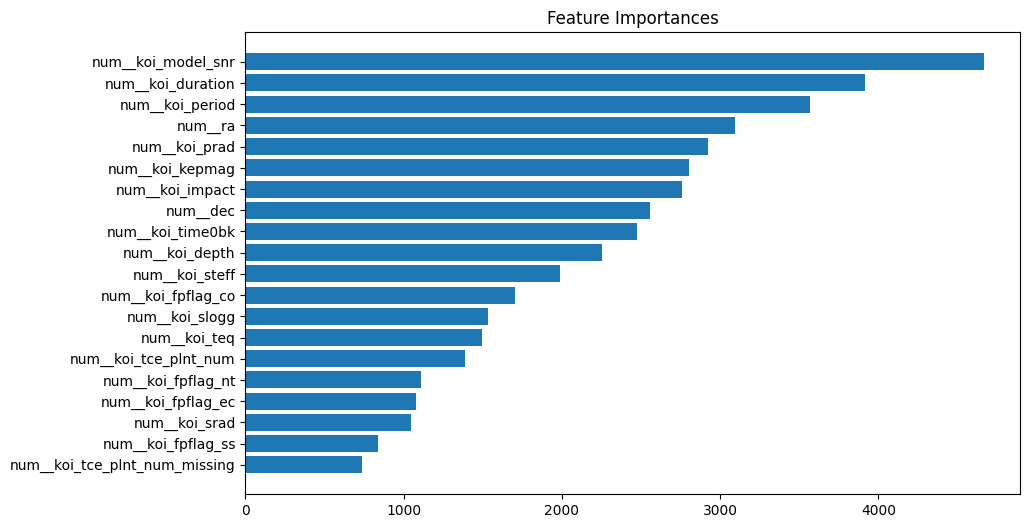

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# After fitting your pipeline
clf_final.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names = clf_final.named_steps["preprocessor"].get_feature_names_out()

# Extract importance
importances = clf_final.named_steps["classifier"].feature_importances_

# Create DataFrame
feat_imp = pd.DataFrame({"feature": feature_names, "importance": importances})
feat_imp = feat_imp.sort_values("importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp["feature"][:20], feat_imp["importance"][:20])  # top 20
plt.gca().invert_yaxis()
plt.title("Feature Importances")
plt.show()



In [36]:
from sklearn.inspection import permutation_importance

r = permutation_importance(clf_final, X_test, y_test, n_repeats=10, random_state=42)

perm_imp = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_imp.head(15))


d:\ML_AI\heart_disease_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_AI\heart_disease_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_AI\heart_disease_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_AI\heart_disease_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_AI\heart_disease_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_AI\heart_disease_en

                          feature  importance_mean  importance_std
1              num__koi_fpflag_ss         0.184318        0.007045
0              num__koi_fpflag_nt         0.171772        0.006796
12             num__koi_model_snr         0.122112        0.006605
2              num__koi_fpflag_co         0.121066        0.005026
3              num__koi_fpflag_ec         0.055724        0.003316
9                   num__koi_prad         0.043021        0.003926
6                 num__koi_impact         0.021223        0.003445
4                 num__koi_period         0.012180        0.002486
8                  num__koi_depth         0.010925        0.003399
20        num__koi_impact_missing         0.009723        0.001799
7               num__koi_duration         0.009462        0.003463
26  num__koi_tce_plnt_num_missing         0.005855        0.001456
17                        num__ra         0.003136        0.002338
11                 num__koi_insol         0.002666        0.00

In [26]:
import joblib
joblib.dump(clf_final, "../models/best_koi_model.pkl")


['../models/best_koi_model.pkl']